best_model_base16_res_drop.pt
2026_Jul_23__16:17_best_model_base16_res_drop.pt
best_model_base8_res_drop_goodtest.pt
best_model_base16_drop.pt
bestest_on_real.pt
best_model_base8.pt
best_model.pt
best_model_base16_res.pt


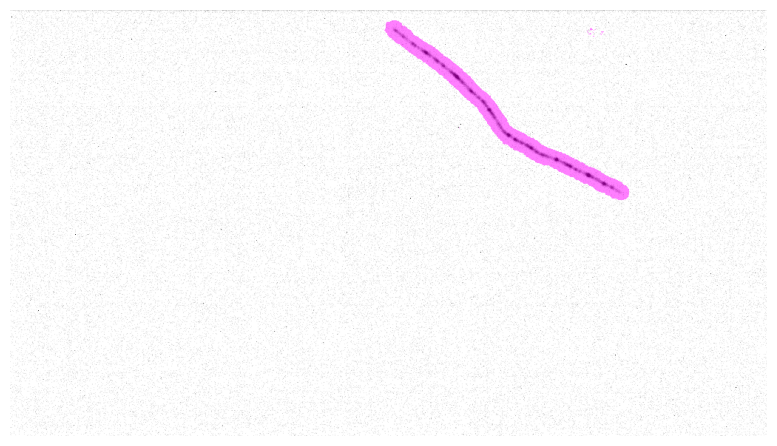

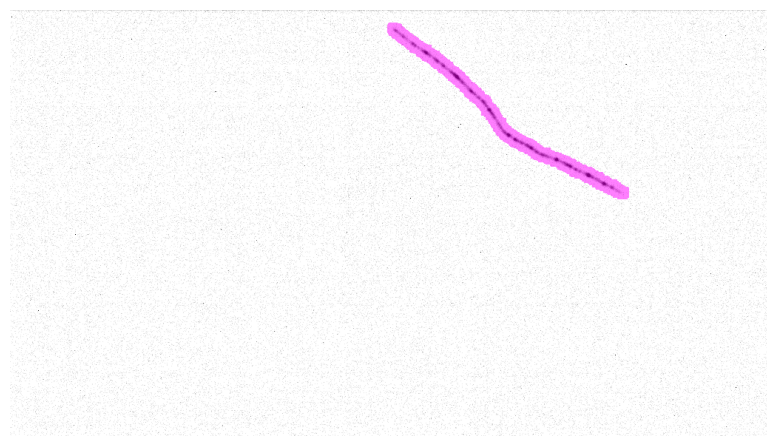

In [73]:
import os, cygnet, torch
from matplotlib import pyplot as plt
import imageio.v3 as iio
import numpy as np
import torchvision.transforms.v2 as transforms

net_folder = "/home/frx/cygnet/saved_models"
for el in os.listdir(net_folder):
	print(el)

metric_test_path = "/home/frx/dataset/image_dataset/test"
raw_path = os.path.join(metric_test_path, "input")
rp_path = os.path.join(metric_test_path, "mask_exp4")

def load_pic_pair(idx):
	raw_image_path = os.path.join(raw_path, f"i_{idx}.png")
	raw = iio.imread(raw_image_path)
	redpix_image_path = os.path.join(rp_path, f"m4_{idx}.png")
	redpix = iio.imread(redpix_image_path)

	return raw, redpix

def get_prediction(net, input, tresh = 0.15):
	device = "cuda"

	net.eval()
	with torch.inference_mode():
		pred = net(cygnet.itrtr(input).unsqueeze(0).to(device))
	spred = torch.sigmoid(pred)
	sspred = (spred > tresh).float()

	return sspred

def compute_energy(img):
	return img.sum()

device = "cuda"

def full_step(net, idx, t=0.15):
		input, mask = load_pic_pair(idx)
		sspred = get_prediction(net, input, t)

		return mask, sspred

def compute_metrics(pred, mask, eps=1e-7):
	"""
	pred: torch tensor, shape (1,1,H,W) or (1,H,W), values in {0,1}
	mask: numpy array (H,W) or (H,W,C), raw ground-truth image
	"""
	pred_np = pred.squeeze().detach().cpu().numpy().astype(bool)

	mask_np = mask
	if mask_np.ndim == 3:
		mask_np = mask_np[..., 0]  # collapse channels if present
	mask_np = (mask_np > 0)

	tp = np.logical_and(pred_np, mask_np).sum()
	fp = np.logical_and(pred_np, ~mask_np).sum()
	fn = np.logical_and(~pred_np, mask_np).sum()

	precision = tp / (tp + fp + eps)
	recall = tp / (tp + fn + eps)
	iou = tp / (tp + fp + fn + eps)
	dice = 2 * tp / (2 * tp + fp + fn + eps)

	return precision, recall, iou, dice

def visualize_prediction(net, idx, t=0.15, alpha=0.5, vmin=200, vmax=210, is_raw=False):
	raw, mask = load_pic_pair(idx)
	pred = get_prediction(net, raw, t)

	pred_np = pred.squeeze().detach().cpu().numpy().astype(bool)

	if is_raw:
		pred_np=mask
	# convert raw to grayscale if it has color channels
	raw_gray = raw
	if raw_gray.ndim == 3:
		raw_gray = raw_gray.mean(axis=-1)
	raw_gray = raw_gray.astype(np.float32)

	# compress dynamic range via explicit vmin/vmax, then normalize
	v_lo = raw_gray.min() if vmin is None else vmin
	v_hi = raw_gray.max() if vmax is None else vmax
	raw_gray = np.clip(raw_gray, v_lo, v_hi)
	raw_gray = (raw_gray - v_lo) / (v_hi - v_lo + 1e-7)

	# invert so background is white, features are dark (saves ink when printed)
	raw_gray = 1.0 - raw_gray

   # build an RGB image: grayscale base, fuchsia overlay where predicted
	overlay = np.stack([raw_gray, raw_gray, raw_gray], axis=-1)
	fuchsia_layer = np.zeros_like(overlay)
	fuchsia_layer[..., 0] = 1.0  # red channel
	fuchsia_layer[..., 2] = 1.0  # blue channel

	overlay = np.where(
		pred_np[..., None],
		(1 - alpha) * overlay + alpha * fuchsia_layer,
		overlay
	)

	plt.figure(figsize=(20, 20, "cm"))
	plt.imshow(overlay)
	#plt.title(f"Segmentation overlay — idx {idx}")
	plt.axis("off")
	plt.tight_layout()
	plt.show()

	#return overlay

net_file = "2026_Jul_23__16:17_best_model_base16_res_drop.pt"
net_path = os.path.join(net_folder, net_file)

net = cygnet.SkipNet(16).to(device)
net.load_state_dict(torch.load(net_path, weights_only=False)['model_state_dict'])
net.eval()

num = len(os.listdir(raw_path))
recompute = False

if recompute:
	precisions, recalls, ious, dices = [], [], [], []

	for idx in range(num):
		mask, pred = full_step(net, idx)
		precision, recall, iou, dice = compute_metrics(pred, mask)
		precisions.append(precision)
		recalls.append(recall)
		ious.append(iou)
		dices.append(dice)

	precisions = np.array(precisions)
	recalls = np.array(recalls)
	ious = np.array(ious)
	dices = np.array(dices)

	print(f"Mean precision: {precisions.mean():.4f} ± {precisions.std():.4f}")
	print(f"Mean recall:    {recalls.mean():.4f} ± {recalls.std():.4f}")
	print(f"Mean IoU:       {ious.mean():.4f} ± {ious.std():.4f}")
	print(f"Mean Dice:      {dices.mean():.4f} ± {dices.std():.4f}")

idx = 6
visualize_prediction(net, idx=idx, is_raw=False)
visualize_prediction(net, idx=idx, is_raw=True)
